# Streaming Data Load

Load `.npz` dumps, separate calibration from science, fftshift,
pair by LO frequency, and extract frequency-switched HI profiles.

Works with any number of LO frequencies (2 for galactic, 4 for M31).

In [1]:
from pathlib import Path
import datetime as dt
import matplotlib.pyplot as plt
import numpy as np

import sys; sys.path.insert(0, '..')
import ugradiolab.plotting as plotting  # applies rcParams
from plotters import plot_hi_spectrum

SAMPLE_RATE_HZ = 2.56e6
NFFT = 1024
HI_REST_MHZ = 1420.405
C_KMS = 299792.458

%matplotlib inline

/home/ikaros/projects/ay-121/.venv/lib/python3.12/site-packages/rtlsdr/__init__.py:19: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


## 1. Load dumps

In [2]:
TARGET = 'm31'
DATA_DIR = Path(f'../../../data/lab04/streaming/{TARGET}')
paths = sorted(DATA_DIR.glob(f'{TARGET}_dump_*.npz'))
N = len(paths)
print(f'{N} dumps in {DATA_DIR}')

with np.load(paths[0], allow_pickle=True) as f:
    N_CH = f['corr01'].shape[0]
    print(f'Keys: {list(f.keys())}')

# Load all
corr00 = np.empty((N, N_CH), dtype=float)
corr11 = np.empty((N, N_CH), dtype=float)
lo_mhz = np.empty(N)
noise_on = np.empty(N, dtype=bool)
unix_t = np.empty(N)
alt_arr = np.empty(N)
az_arr = np.empty(N)

for i, p in enumerate(paths):
    with np.load(p, allow_pickle=True) as f:
        corr00[i] = f['corr00']
        corr11[i] = f['corr11']
        lo_mhz[i] = float(f['lo_freq_mhz'])
        noise_on[i] = bool(f['noise_on'])
        unix_t[i] = float(f['time'])
        alt_arr[i] = float(f['alt_deg'])
        az_arr[i] = float(f['az_deg'])

# Separate
cal = noise_on
sci = ~noise_on
lo_unique = sorted(set(lo_mhz[sci]))

print(f'Cal: {cal.sum()}, Science: {sci.sum()}')
print(f'LO frequencies: {lo_unique} MHz')
for lo in lo_unique:
    print(f'  LO={lo}: {(sci & (lo_mhz == lo)).sum()} science dumps')

714 dumps in ../../../data/lab04/streaming/m31
Keys: ['corr00', 'corr01', 'corr11', 'time', 'lo_freq_mhz', 'noise_on', 'target_name', 'alt_deg', 'az_deg', 'ra_deg', 'dec_deg', 'seq']
Cal: 20, Science: 694
LO frequencies: [np.float64(1420.0), np.float64(1421.0), np.float64(1422.0), np.float64(1423.0), np.float64(1424.0)] MHz
  LO=1420.0: 140 science dumps
  LO=1421.0: 140 science dumps
  LO=1422.0: 138 science dumps
  LO=1423.0: 138 science dumps
  LO=1424.0: 138 science dumps


## 2. fftshift + mask DC

In [3]:
# fftshift (complex I/Q FFT: reorder to [-fs/2, ..., +fs/2])
corr00 = np.fft.fftshift(corr00, axes=-1)
corr11 = np.fft.fftshift(corr11, axes=-1)

# Mask DC bin (LO spike at channel 512 after fftshift)
DC_BIN = NFFT // 2
corr00[:, DC_BIN] = np.nan
corr11[:, DC_BIN] = np.nan

# For LO=1420: the LO spike at DC coincides with sky 1420.0 MHz,
# near the HI line. Mask 2 bins below DC to suppress leakage.
# For other LOs: the DC mask already covers the LO spike and
# sky 1420.0 MHz falls at a normal science channel -- no extra mask.
f_bb_mhz = np.fft.fftshift(np.fft.fftfreq(NFFT, d=1.0/SAMPLE_RATE_HZ)) / 1e6

lo1420_rows = np.where(lo_mhz == 1420.0)[0]
if len(lo1420_rows) > 0:
    for ch in [DC_BIN - 2, DC_BIN - 1]:
        corr00[lo1420_rows, ch] = np.nan
        corr11[lo1420_rows, ch] = np.nan
    print(f'Masked DC leakage: channels {DC_BIN-2}, {DC_BIN-1} (LO=1420 only, {len(lo1420_rows)} dumps)')

# Stokes I = total intensity (both polarisations)
stokes_I = corr00 + corr11

# Baseband frequency axis (fftshifted)
df_khz = SAMPLE_RATE_HZ / NFFT / 1e3

print(f'Baseband: [{f_bb_mhz[0]:.3f}, {f_bb_mhz[-1]:.3f}] MHz')
print(f'dnu = {df_khz:.2f} kHz, dv = {C_KMS * df_khz*1e3 / (HI_REST_MHZ*1e6):.2f} km/s')
print(f'Masked DC bin: channel {DC_BIN}')

Masked DC leakage: channels 510, 511 (LO=1420 only, 144 dumps)
Baseband: [-1.280, 1.278] MHz
dnu = 2.50 kHz, dv = 0.53 km/s
Masked DC bin: channel 512


## 2a. RFI flagging + outlier dump filter

1. **Per-channel RFI**: NaN-aware rolling median (window=15) + 5sigma MAD threshold,
   flags both positive spikes and negative dropouts.
2. **Per-dump outlier**: spectral shape comparison within each LO group -- flag
   dumps where >20% of channels deviate >10% from the group median spectrum.

In [4]:
import pandas as pd
import warnings

# --- Per-channel RFI flagging (NaN-aware, both directions) ---
RFI_WINDOW = 15    # channels (~52 kHz) for rolling median
RFI_SIGMA  = 5.0   # flag threshold in units of local MAD

n_flagged_total = 0
for i in range(N):
    spec = stokes_I[i]
    local_med = pd.Series(spec).rolling(
        RFI_WINDOW, center=True, min_periods=1,
    ).median().to_numpy()
    resid = spec - local_med
    mad = np.nanmedian(np.abs(resid))
    sigma = mad / 0.6745
    bad = np.abs(resid) > RFI_SIGMA * sigma  # both positive and negative
    n_bad = np.sum(bad)
    if n_bad > 0:
        stokes_I[i, bad] = np.nan
        n_flagged_total += n_bad

print(f'RFI flagging: {n_flagged_total} samples masked across {N} dumps')

# --- Per-dump outlier filter (spectral shape comparison) ---
SHAPE_DEV_THRESH = 0.10   # flag channels >10% from median ratio
SHAPE_FRAC_THRESH = 0.20  # flag dump if >20% of channels are bad

# Group science dumps by LO (single target, so no cell grouping needed)
n_outlier_removed = 0
outlier_mask = np.zeros(N, dtype=bool)  # True = flagged

for lo in lo_unique:
    lo_sci_idx = np.where(sci & (lo_mhz == lo))[0]
    if len(lo_sci_idx) < 3:
        continue

    spectra = stokes_I[lo_sci_idx]
    with warnings.catch_warnings():
        warnings.simplefilter('ignore', RuntimeWarning)
        med_spec = np.nanmedian(spectra, axis=0)

    if np.all(np.isnan(med_spec)) or np.nanmax(np.abs(med_spec)) == 0:
        continue

    for idx in lo_sci_idx:
        with warnings.catch_warnings():
            warnings.simplefilter('ignore', RuntimeWarning)
            ratio = stokes_I[idx] / med_spec
        valid = np.isfinite(ratio)
        if valid.sum() == 0:
            frac_bad = 1.0
        else:
            frac_bad = np.sum(np.abs(ratio[valid] - 1.0) > SHAPE_DEV_THRESH) / valid.sum()

        if frac_bad > SHAPE_FRAC_THRESH:
            outlier_mask[idx] = True
            n_outlier_removed += 1

# Apply outlier mask: NaN out flagged dumps so they don't contribute to pairing
for idx in np.where(outlier_mask)[0]:
    stokes_I[idx, :] = np.nan

# Update masks: flagged science dumps are effectively removed
sci = sci & ~outlier_mask

print(f'Outlier dump filter (spectral shape): removed {n_outlier_removed} dumps')
print(f'  (flag if >{SHAPE_FRAC_THRESH:.0%} of channels deviate '
      f'>{SHAPE_DEV_THRESH:.0%} from LO group median)')
print(f'Remaining science: {sci.sum()} dumps')

# Summary: which channels were flagged across all non-outlier dumps
flagged_any = np.any(np.isnan(stokes_I[~outlier_mask]), axis=0)
flagged_chs = np.where(flagged_any)[0]
rfi_chs = flagged_chs[flagged_chs != DC_BIN]

print(f'\nChannels with any flags (excl. DC): {len(rfi_chs)}')
if len(rfi_chs) > 0:
    bands = []
    start = rfi_chs[0]
    prev = rfi_chs[0]
    for ch in rfi_chs[1:]:
        if ch == prev + 1:
            prev = ch
        else:
            bands.append((start, prev))
            start = ch
            prev = ch
    bands.append((start, prev))
    for b_start, b_end in bands:
        f_lo = f_bb_mhz[b_start]
        f_hi = f_bb_mhz[b_end]
        width = b_end - b_start + 1
        print(f'  ch {b_start}-{b_end} ({width} ch)  '
              f'baseband [{f_lo:+.3f}, {f_hi:+.3f}] MHz')

RFI flagging: 18408 samples masked across 714 dumps
Outlier dump filter (spectral shape): removed 0 dumps
  (flag if >20% of channels deviate >10% from LO group median)
Remaining science: 694 dumps

Channels with any flags (excl. DC): 809
  ch 75-76 (2 ch)  baseband [-1.093, -1.090] MHz
  ch 106-107 (2 ch)  baseband [-1.015, -1.012] MHz
  ch 110-119 (10 ch)  baseband [-1.005, -0.983] MHz
  ch 121-124 (4 ch)  baseband [-0.978, -0.970] MHz
  ch 126-511 (386 ch)  baseband [-0.965, -0.003] MHz
  ch 513-888 (376 ch)  baseband [+0.003, +0.940] MHz
  ch 890-912 (23 ch)  baseband [+0.945, +1.000] MHz
  ch 959-960 (2 ch)  baseband [+1.117, +1.120] MHz
  ch 963-966 (4 ch)  baseband [+1.127, +1.135] MHz


## 2b. Mean Stokes I per LO band

/tmp/ipykernel_298839/270642889.py:9: RuntimeWarning: Mean of empty slice
  mean_sci = np.nanmean(stokes_I[sci_mask], axis=0)
/tmp/ipykernel_298839/270642889.py:15: RuntimeWarning: Mean of empty slice
  mean_cal = np.nanmean(stokes_I[cal_mask], axis=0)
/tmp/ipykernel_298839/270642889.py:22: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


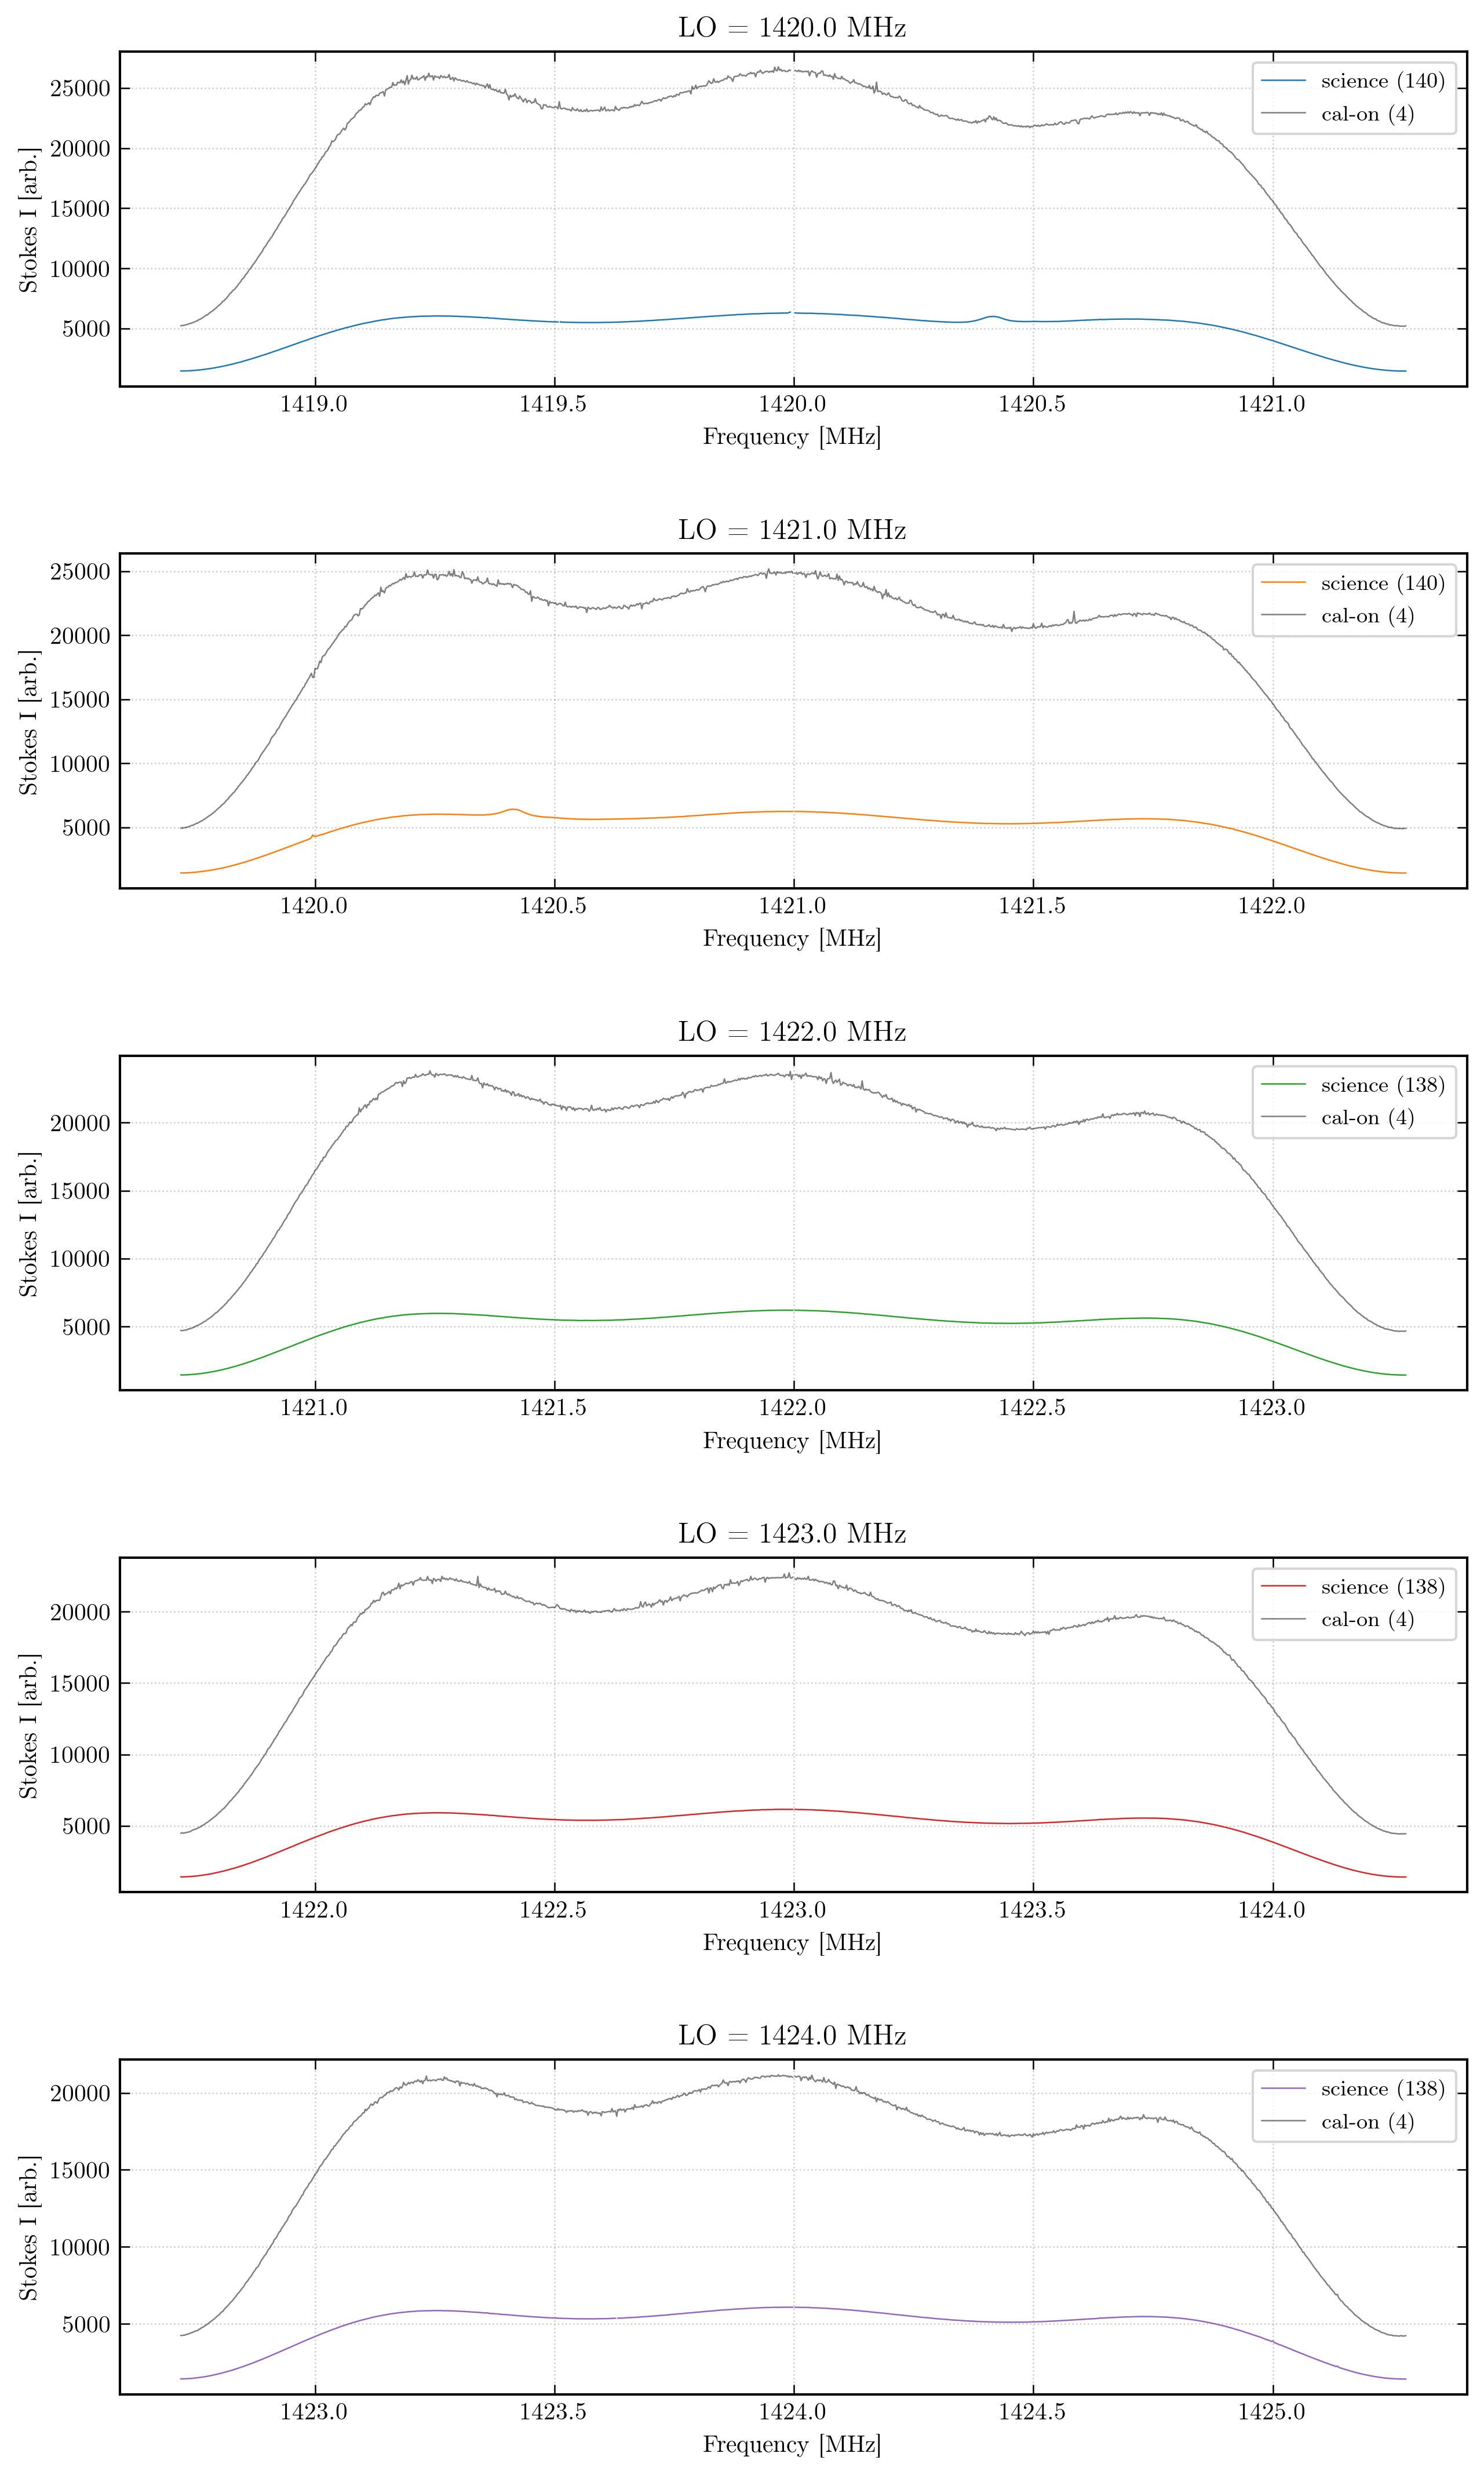

In [5]:
fig, axes = plt.subplots(len(lo_unique), 1, figsize=(10, 3.5 * len(lo_unique)),
                         gridspec_kw={'hspace': 0.5})
if len(lo_unique) == 1:
    axes = [axes]

for i, lo in enumerate(lo_unique):
    sci_mask = sci & (lo_mhz == lo)
    cal_mask = cal & (lo_mhz == lo)
    mean_sci = np.nanmean(stokes_I[sci_mask], axis=0)
    f_sky = lo + f_bb_mhz

    ax = axes[i]
    ax.plot(f_sky, mean_sci, lw=plotting.LW_FINE, color=f'C{i}', label=f'science ({sci_mask.sum()})')
    if cal_mask.sum() > 0:
        mean_cal = np.nanmean(stokes_I[cal_mask], axis=0)
        ax.plot(f_sky, mean_cal, lw=plotting.LW_FINE, color='k', alpha=0.5, label=f'cal-on ({cal_mask.sum()})')
    ax.set_xlabel('Frequency [MHz]')
    ax.set_ylabel('Stokes I [arb.]')
    ax.set_title(f'LO = {lo} MHz')
    ax.legend(fontsize=plotting.LEGEND_SIZE)

fig.tight_layout()
plt.show()

## 3. Pair by LO frequency and compute switched spectra

For each adjacent LO pair (lo1, lo2), compute `R = (I1 - I2) / I2`.
The overlap region (trimmed 256 kHz from each edge) isolates the line profile.

In [6]:
import astropy.coordinates as ac
import astropy.units as u_ast
from astropy.time import Time as AstroTime

# --- LSR velocity correction ---
# Single target, single night: one correction for all dumps.
LEO_LOCATION = ac.EarthLocation(
    lat=37.9183 * u_ast.deg, lon=-122.1067 * u_ast.deg, height=304 * u_ast.m)
_apex = ac.SkyCoord(
    ra=270 * u_ast.deg, dec=30 * u_ast.deg,
    frame='fk4', equinox='B1900.0',
).transform_to('icrs')
V_SUN_KMS = 20.0

# Use first dump's RA/Dec and mean science timestamp
with np.load(paths[0], allow_pickle=True) as f:
    ra_tgt = float(f['ra_deg'])
    dec_tgt = float(f['dec_deg'])
mean_t = np.mean(unix_t[sci])

t_obs = AstroTime(mean_t, format='unix')
sc_tgt = ac.SkyCoord(ra=ra_tgt * u_ast.deg, dec=dec_tgt * u_ast.deg, frame='icrs')
v_helio = sc_tgt.radial_velocity_correction(
    kind='heliocentric', obstime=t_obs, location=LEO_LOCATION,
).to(u_ast.km / u_ast.s).value
v_sun = V_SUN_KMS * np.cos(sc_tgt.separation(_apex).rad)
V_CORR_LSR = v_helio + v_sun

print(f'LSR correction: v_corr = {V_CORR_LSR:+.2f} km/s')
print(f'  (helio {v_helio:+.2f} + solar {v_sun:+.2f})')

# Build adjacent LO pairs
lo_pairs = [(lo_unique[i], lo_unique[i+1]) for i in range(len(lo_unique)-1)]
print(f'\nLO pairs: {lo_pairs}')

# Channel shift for 1 MHz LO offset
lo_step_mhz = lo_unique[1] - lo_unique[0] if len(lo_unique) > 1 else 1.0
shift_ch = round(lo_step_mhz / (SAMPLE_RATE_HZ / NFFT / 1e6))
print(f'LO step: {lo_step_mhz} MHz = {shift_ch} channels')

# Edge trim: 256 kHz from each edge of overlap (avoids DC leakage halos)
EDGE_TRIM_MHZ = 0.256

pair_results = {}
for lo1, lo2 in lo_pairs:
    # Get science dumps at each LO
    idx1 = np.where(sci & (lo_mhz == lo1))[0]
    idx2 = np.where(sci & (lo_mhz == lo2))[0]
    n_p = min(len(idx1), len(idx2))
    
    I1 = stokes_I[idx1[:n_p]]  # (n_p, N_CH)
    I2 = stokes_I[idx2[:n_p]]
    
    # Frequency-switched ratio
    R = (I1 - I2) / I2
    R_mean = np.nanmean(R, axis=0)
    R_std = np.nanstd(R, axis=0) / np.sqrt(n_p)
    
    # Sky frequency axes
    f_sky_1 = lo1 + f_bb_mhz
    f_sky_2 = lo2 + f_bb_mhz
    
    # Velocity axes (LSR-corrected)
    v_topo_1 = C_KMS * (1 - f_sky_1 / HI_REST_MHZ)
    v_lsr_1 = v_topo_1 + V_CORR_LSR
    
    # Overlap region, trimmed by EDGE_TRIM_MHZ on each side
    f_overlap_lo = max(f_sky_1[0], f_sky_2[0]) + EDGE_TRIM_MHZ
    f_overlap_hi = min(f_sky_1[-1], f_sky_2[-1]) - EDGE_TRIM_MHZ
    overlap_mask = (f_sky_1 >= f_overlap_lo) & (f_sky_1 <= f_overlap_hi)
    
    pair_results[(lo1, lo2)] = {
        'R_mean': R_mean, 'R_std': R_std,
        'f_sky_1': f_sky_1, 'f_sky_2': f_sky_2,
        'v_lsr': v_lsr_1,
        'overlap_mask': overlap_mask, 'n_pairs': n_p,
    }
    
    v_ov = v_lsr_1[overlap_mask]
    print(f'  ({lo1}, {lo2}): {n_p} pairs, '
          f'usable [{f_overlap_lo:.2f}, {f_overlap_hi:.2f}] MHz, '
          f'v_LSR [{v_ov[-1]:.0f}, {v_ov[0]:.0f}] km/s')

LSR correction: v_corr = +3.22 km/s
  (helio -1.18 + solar +4.40)

LO pairs: [(np.float64(1420.0), np.float64(1421.0)), (np.float64(1421.0), np.float64(1422.0)), (np.float64(1422.0), np.float64(1423.0)), (np.float64(1423.0), np.float64(1424.0))]
LO step: 1.0 MHz = 400 channels
  (1420.0, 1421.0): 140 pairs, usable [1419.98, 1421.02] MHz, v_LSR [-127, 93] km/s
  (1421.0, 1422.0): 138 pairs, usable [1420.98, 1422.02] MHz, v_LSR [-338, -118] km/s
  (1422.0, 1423.0): 138 pairs, usable [1421.98, 1423.02] MHz, v_LSR [-549, -329] km/s
  (1423.0, 1424.0): 138 pairs, usable [1422.98, 1424.02] MHz, v_LSR [-760, -540] km/s


/tmp/ipykernel_298839/3637215287.py:56: RuntimeWarning: Mean of empty slice
  R_mean = np.nanmean(R, axis=0)
/home/ikaros/projects/ay-121/.venv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


## 4. HI profiles

### 4a. Full-band R for each pair

Raw frequency-switched ratio R = (I1 - I2) / I2 across the full band.

/tmp/ipykernel_298839/1778715807.py:23: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


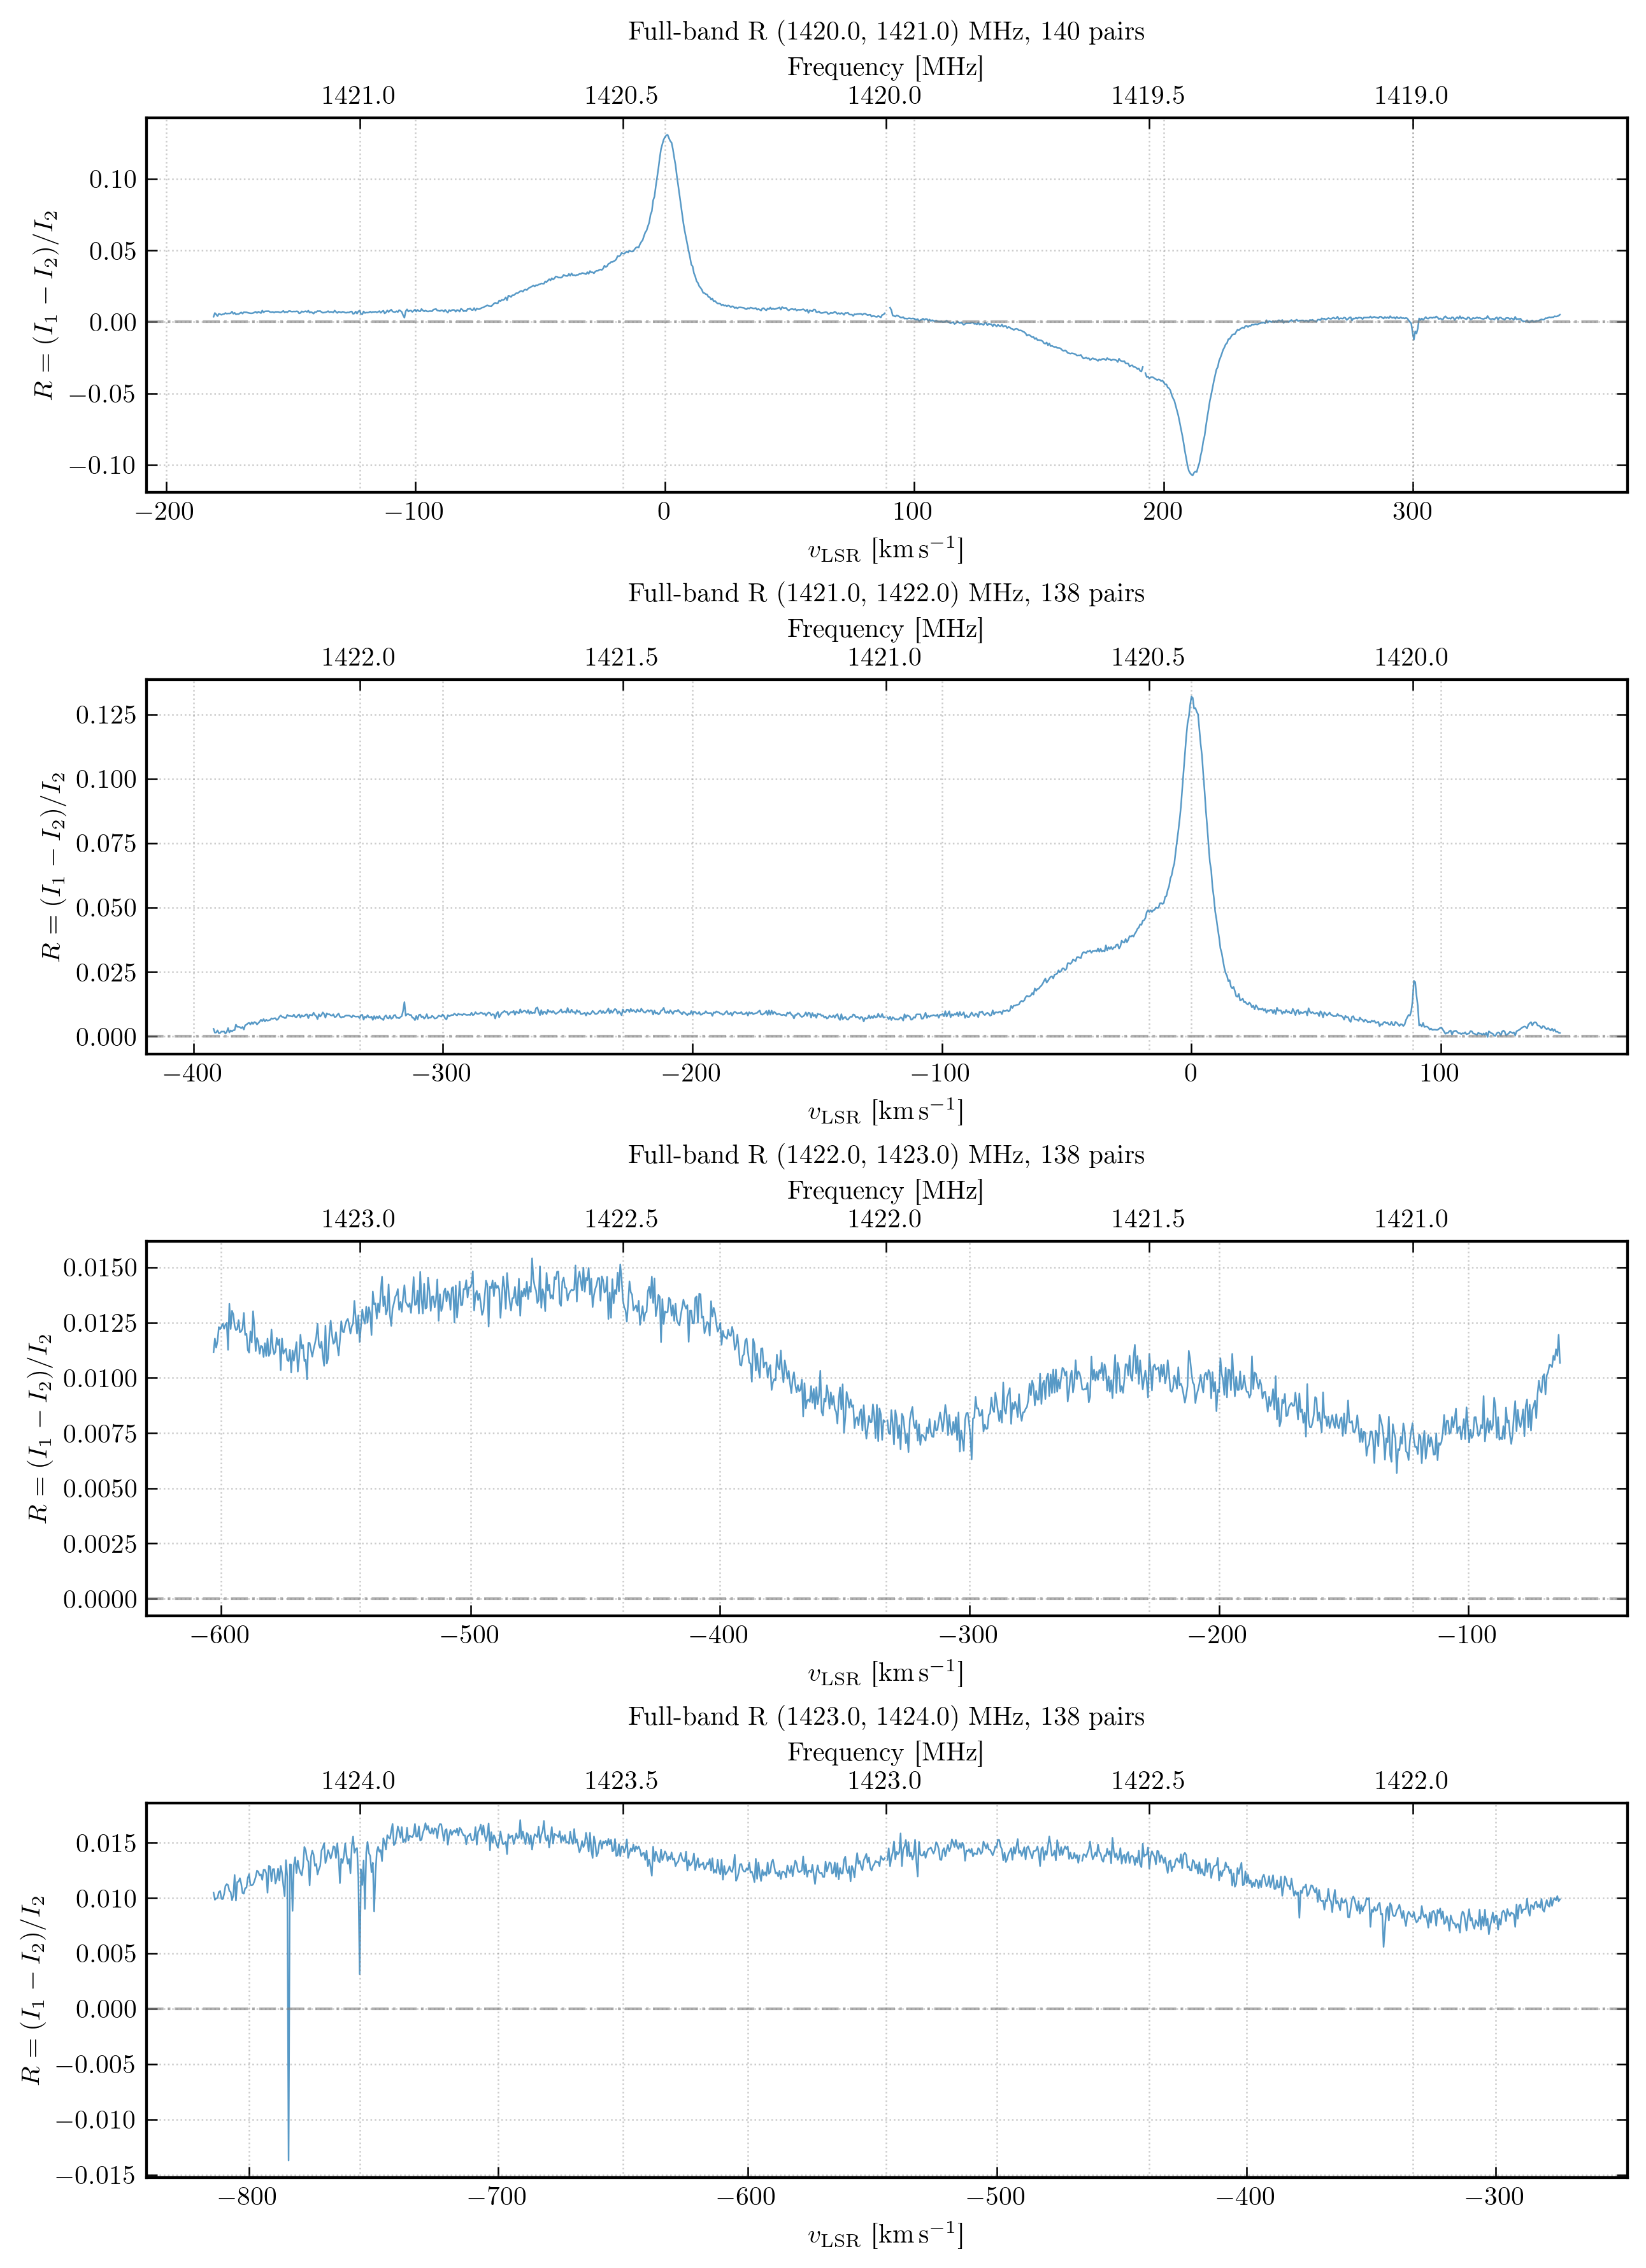

In [7]:
n_pairs_plot = len(pair_results)
fig, axes = plt.subplots(n_pairs_plot, 1, figsize=(10, 3.5 * n_pairs_plot),
                         gridspec_kw={'hspace': 0.5})
if n_pairs_plot == 1:
    axes = [axes]

for row, ((lo1, lo2), pr) in enumerate(pair_results.items()):
    ax = axes[row]
    v_lsr = pr['v_lsr']
    plot_hi_spectrum(v_lsr, pr['R_mean'], color='C0',
                     ylabel=r"$R = (I_1 - I_2) / I_2$",
                     xlabel=r"$v_\mathrm{LSR}$ [km\,s$^{-1}$]",
                     title=f'Full-band R ({lo1}, {lo2}) MHz, {pr["n_pairs"]} pairs',
                     ax=ax)

    ax_freq = ax.twiny()
    v_lo, v_hi = ax.get_xlim()
    ax_freq.set_xlim(HI_REST_MHZ * (1 - (v_lo - V_CORR_LSR) / C_KMS),
                     HI_REST_MHZ * (1 - (v_hi - V_CORR_LSR) / C_KMS))
    ax_freq.set_xlabel('Frequency [MHz]')
    ax_freq.ticklabel_format(axis='x', useOffset=False)

fig.tight_layout()
plt.show()

### 4b. R in overlap region only

/tmp/ipykernel_298839/383905530.py:27: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


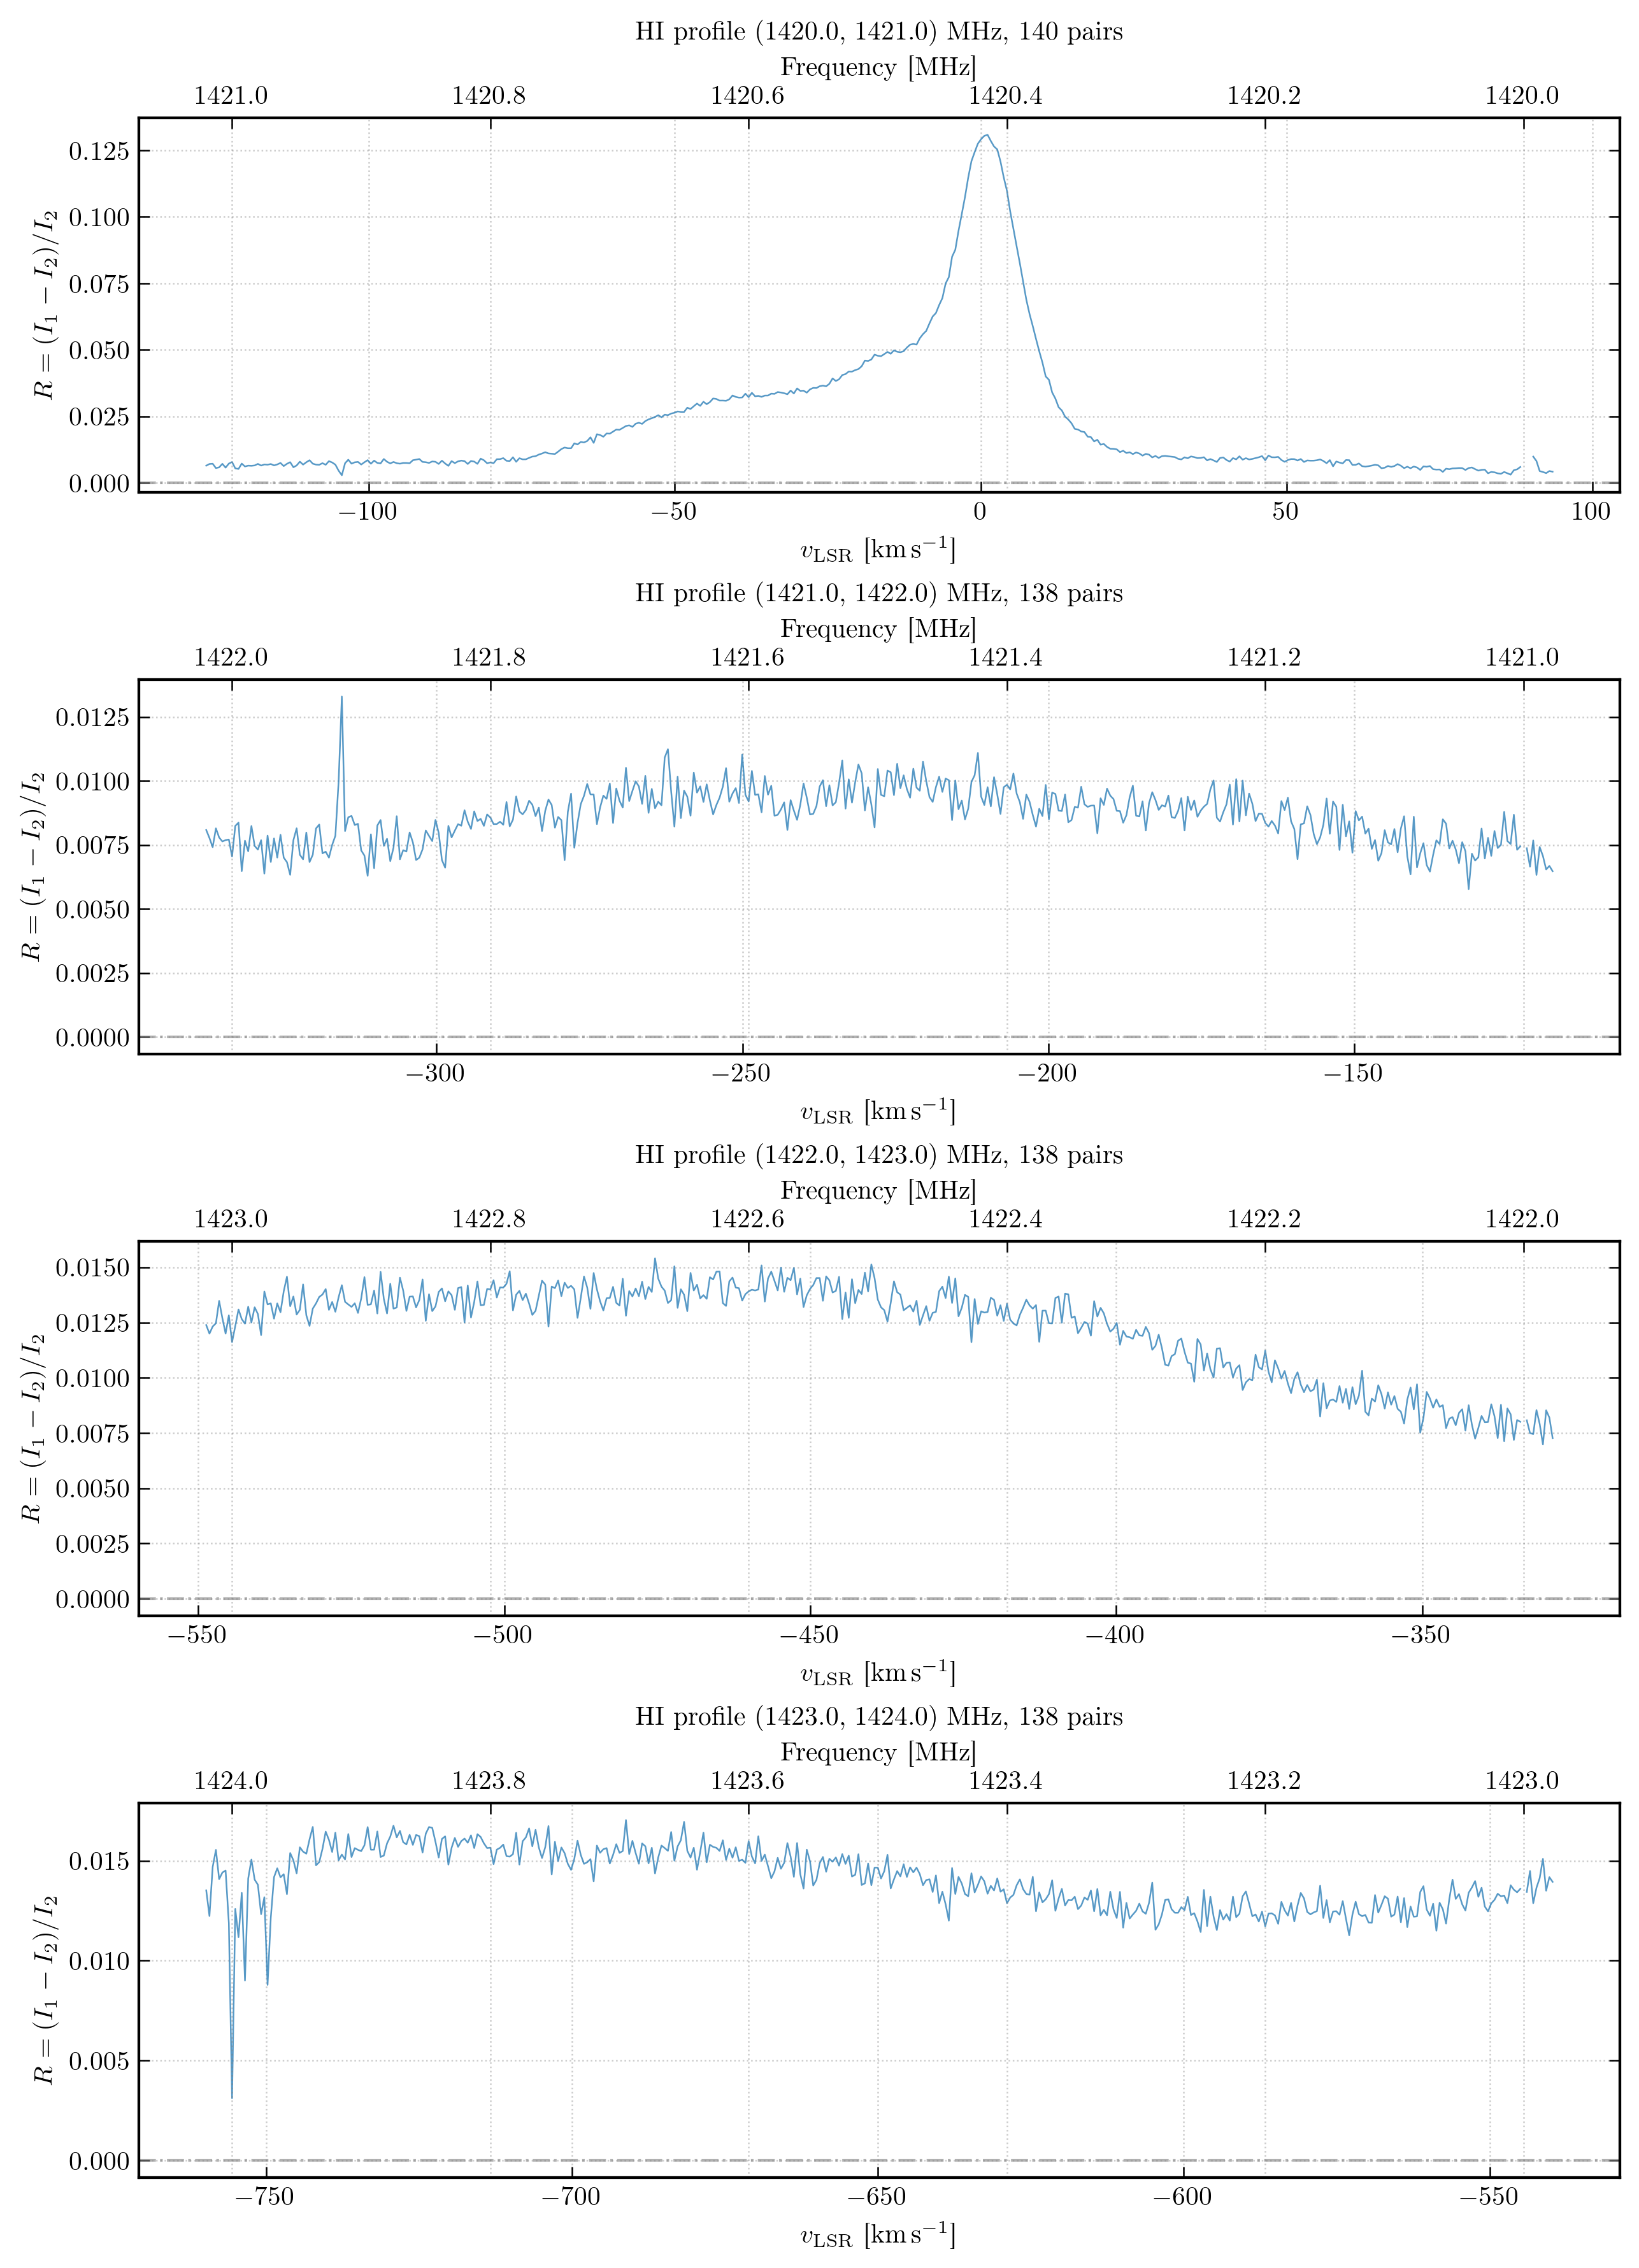

In [8]:
n_pairs_plot = len(pair_results)
fig, axes = plt.subplots(n_pairs_plot, 1, figsize=(10, 3.5 * n_pairs_plot),
                         gridspec_kw={'hspace': 0.5})
if n_pairs_plot == 1:
    axes = [axes]

for row, ((lo1, lo2), pr) in enumerate(pair_results.items()):
    mask = pr['overlap_mask']

    ax = axes[row]
    v_lsr = pr['v_lsr'][mask]
    profile = pr['R_mean'][mask]
    plot_hi_spectrum(v_lsr, profile, color='C0',
                     ylabel=r"$R = (I_1 - I_2) / I_2$",
                     xlabel=r"$v_\mathrm{LSR}$ [km\,s$^{-1}$]",
                     title=f'HI profile ({lo1}, {lo2}) MHz, {pr["n_pairs"]} pairs',
                     ax=ax)

    # Top axis: frequency
    ax_freq = ax.twiny()
    v_lo, v_hi = ax.get_xlim()
    ax_freq.set_xlim(HI_REST_MHZ * (1 - (v_lo - V_CORR_LSR) / C_KMS),
                     HI_REST_MHZ * (1 - (v_hi - V_CORR_LSR) / C_KMS))
    ax_freq.set_xlabel('Frequency [MHz]')
    ax_freq.ticklabel_format(axis='x', useOffset=False)

fig.tight_layout()
plt.show()

### 4c. All pairs combined

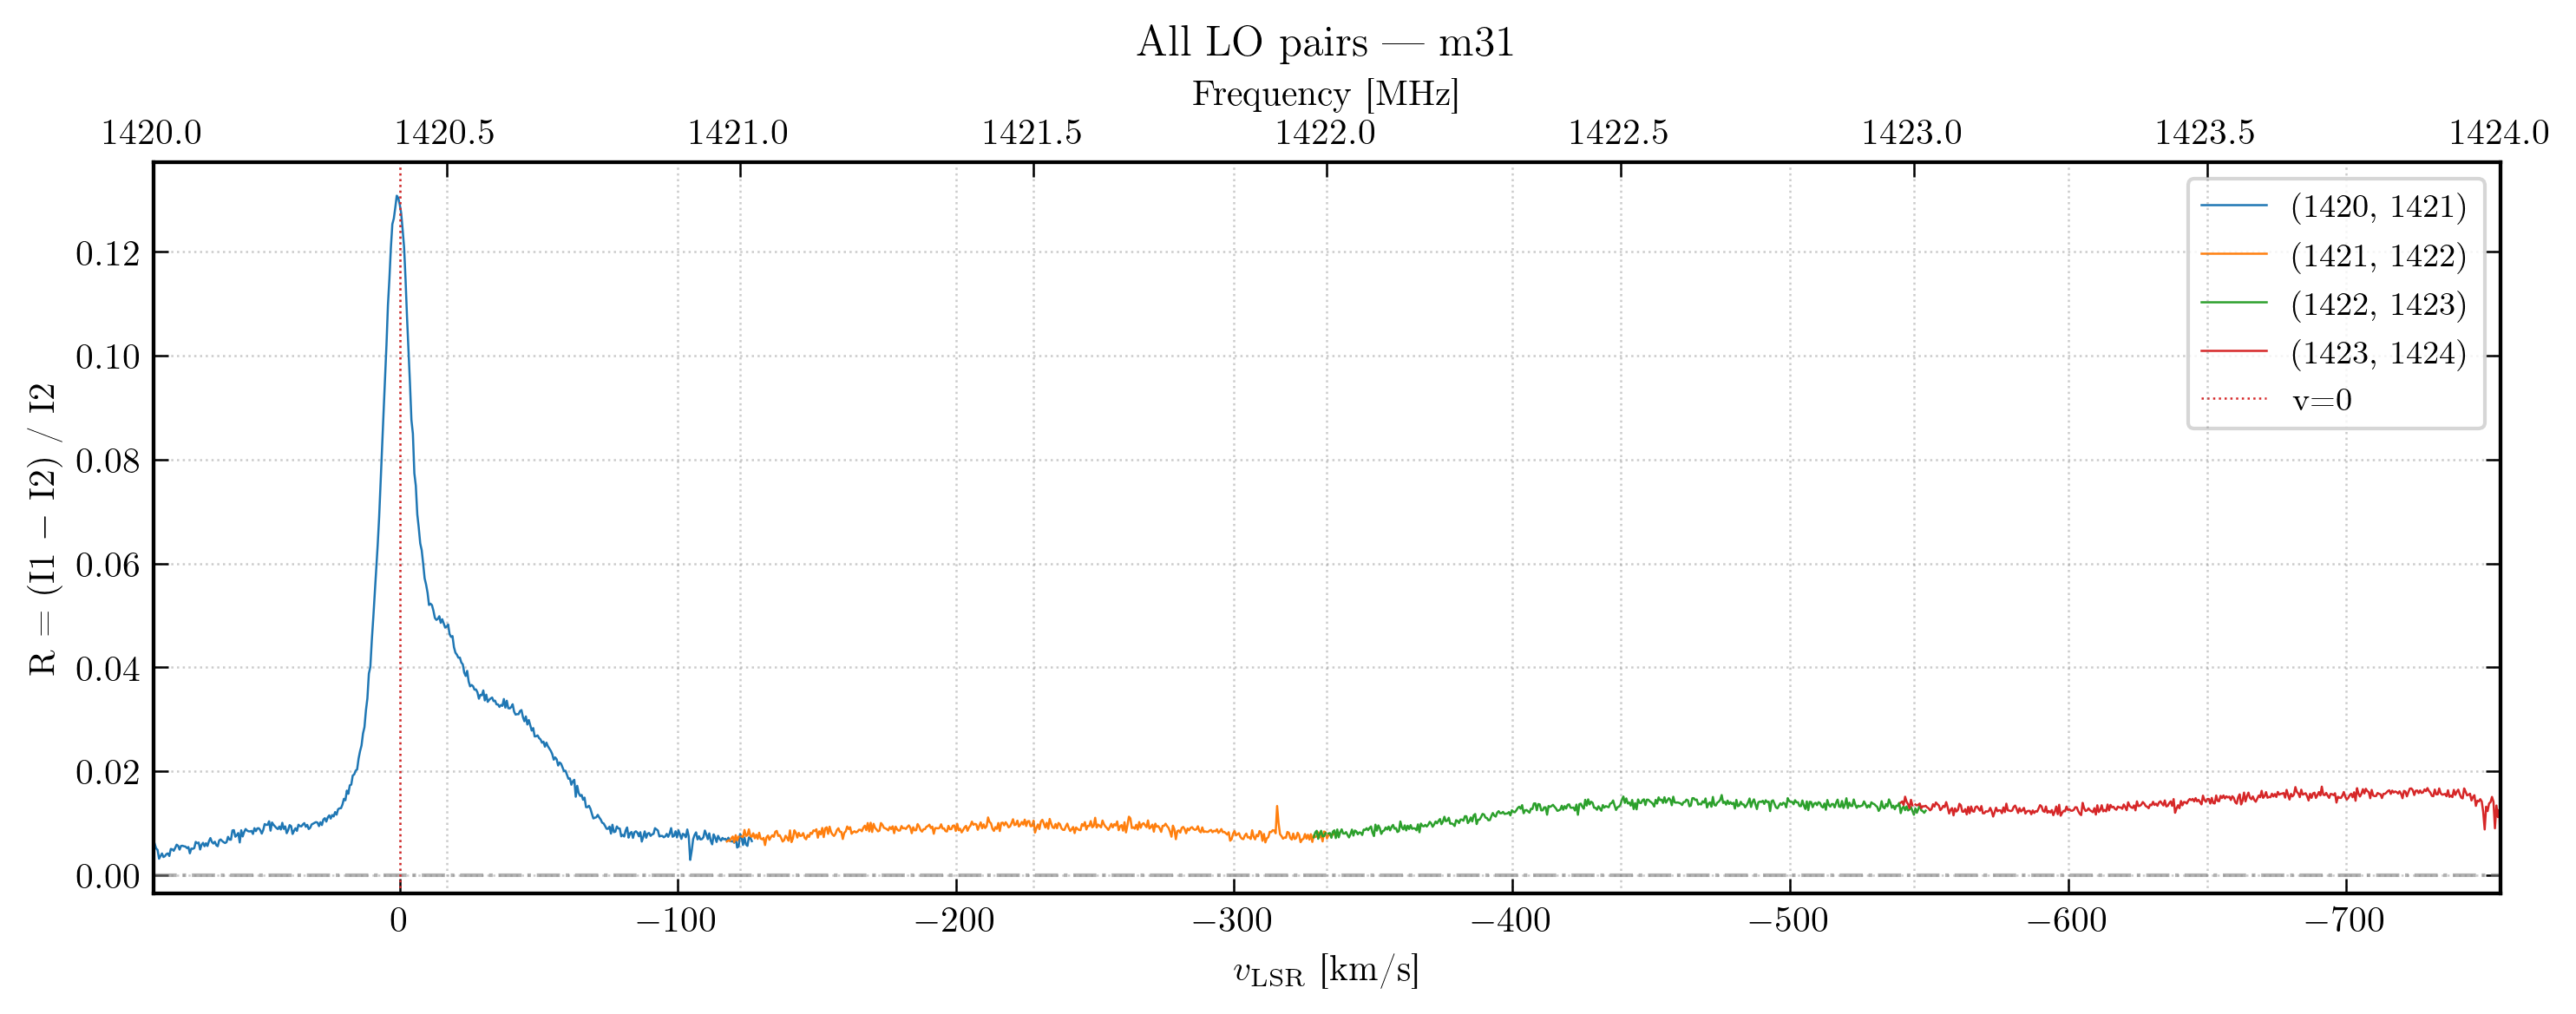

In [9]:
fig, ax = plt.subplots(figsize=(10, 4))

for i, ((lo1, lo2), pr) in enumerate(pair_results.items()):
    mask = pr['overlap_mask']
    v_lsr = pr['v_lsr'][mask]
    ax.plot(v_lsr, pr['R_mean'][mask], lw=plotting.LW_FINE, color=f'C{i}',
            label=f'({lo1:.0f}, {lo2:.0f})')

plotting.zero_line(ax)
ax.axvline(0, color='C3', lw=plotting.LW_FINE, ls=':', label='v=0')
ax.set_xlabel(r'$v_\mathrm{LSR}$ [km/s]')
ax.set_ylabel('R = (I1 - I2) / I2')
ax.set_title(f'All LO pairs --- {TARGET}')
ax.legend(fontsize=plotting.LEGEND_SIZE)

# Limit to 1420-1424 MHz
f_lo_lim, f_hi_lim = 1420.0, 1424.0
v_lo_lim = C_KMS * (1 - f_lo_lim / HI_REST_MHZ) + V_CORR_LSR
v_hi_lim = C_KMS * (1 - f_hi_lim / HI_REST_MHZ) + V_CORR_LSR
ax.set_xlim(v_lo_lim, v_hi_lim)

ax_freq = ax.twiny()
ax_freq.set_xlim(f_lo_lim, f_hi_lim)
ax_freq.set_xlabel('Frequency [MHz]')
ax_freq.ticklabel_format(axis='x', useOffset=False)

fig.tight_layout()
plt.show()

### 4d. Chips 1-2 (M31 velocity range)

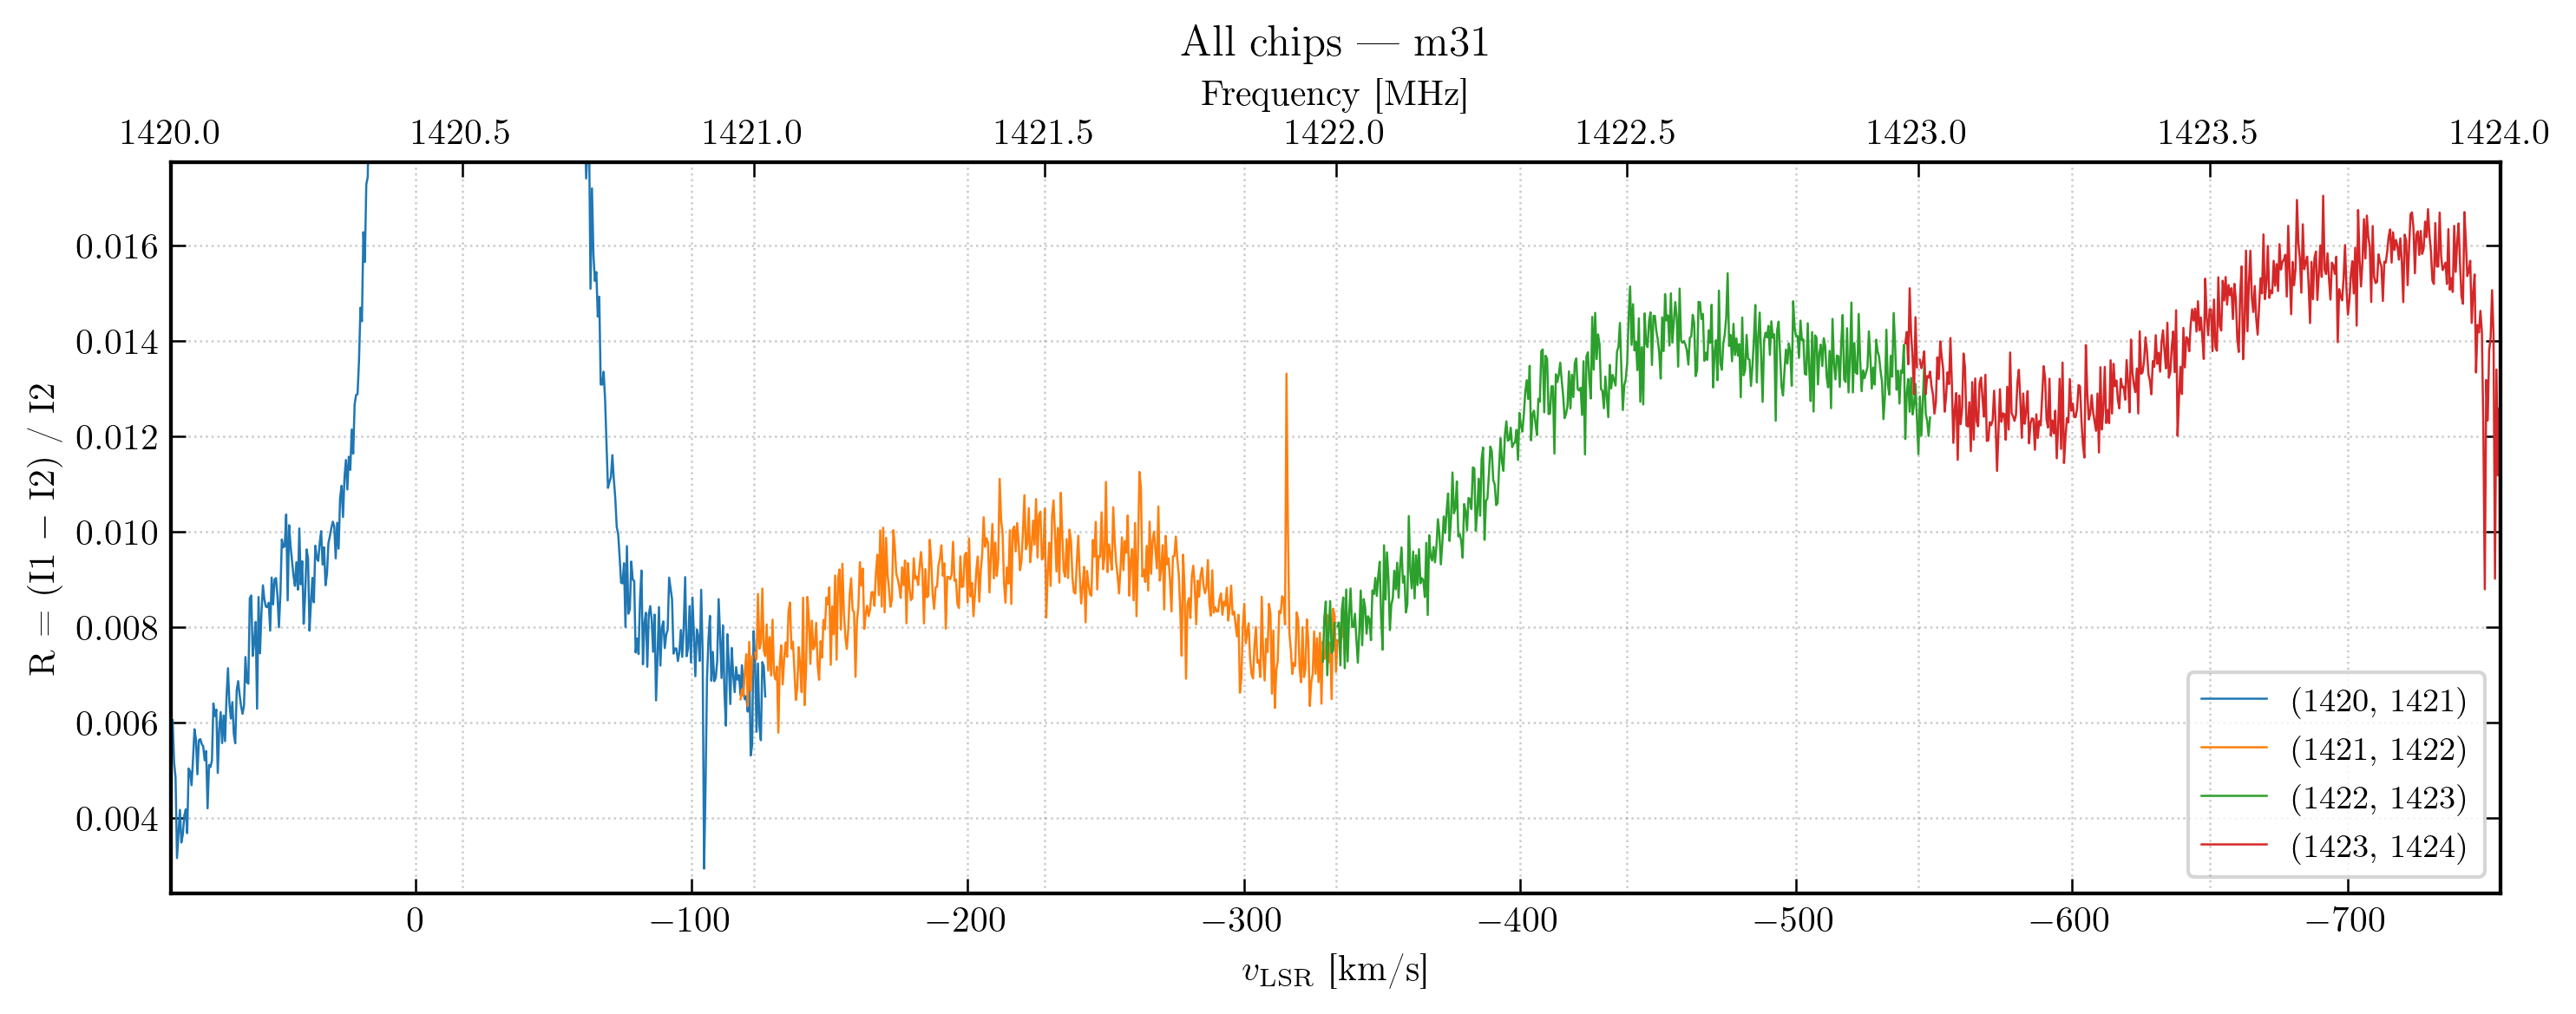

In [10]:
fig, ax = plt.subplots(figsize=(10, 4))

# Plot all chips
for i, ((lo1, lo2), pr) in enumerate(pair_results.items()):
    mask = pr['overlap_mask']
    v_lsr = pr['v_lsr'][mask]

    ax.plot(v_lsr, pr['R_mean'][mask], lw=plotting.LW_FINE, color=f'C{i}',
            label=f'({lo1:.0f}, {lo2:.0f})')

# Set ylim from chips 1-3 only (exclude chip 0 MW peak)
r_vals = []
for i, ((lo1, lo2), pr) in enumerate(pair_results.items()):
    if i == 0:
        continue
    mask = pr['overlap_mask']
    r_vals.append(pr['R_mean'][mask])
if r_vals:
    r_concat = np.concatenate(r_vals)
    y_lo = np.nanmin(r_concat)
    y_hi = np.nanmax(r_concat)
    margin = (y_hi - y_lo) * 0.05  # mpl default ~5% padding
    ax.set_ylim(y_lo - margin, y_hi + margin)

plotting.zero_line(ax)
ax.set_xlabel(r'$v_\mathrm{LSR}$ [km/s]')
ax.set_ylabel('R = (I1 - I2) / I2')
ax.set_title(f'All chips --- {TARGET}')
ax.legend(fontsize=plotting.LEGEND_SIZE)

# Limit to 1420-1424 MHz
f_lo_lim, f_hi_lim = 1420.0, 1424.0
v_lo_lim = C_KMS * (1 - f_lo_lim / HI_REST_MHZ) + V_CORR_LSR
v_hi_lim = C_KMS * (1 - f_hi_lim / HI_REST_MHZ) + V_CORR_LSR
ax.set_xlim(v_lo_lim, v_hi_lim)

ax_freq = ax.twiny()
ax_freq.set_xlim(f_lo_lim, f_hi_lim)
ax_freq.set_xlabel('Frequency [MHz]')
ax_freq.ticklabel_format(axis='x', useOffset=False)

fig.tight_layout()
plt.show()

## 5. Summary

In [11]:
t0 = dt.datetime.fromtimestamp(unix_t[0], tz=dt.UTC)
t1 = dt.datetime.fromtimestamp(unix_t[-1], tz=dt.UTC)
wall = unix_t[-1] - unix_t[0]
cadence = float(np.median(np.diff(unix_t[sci])))

print(f'Target:     {TARGET}')
print(f'Start:      {t0:%Y-%m-%d %H:%M:%S UTC}')
print(f'End:        {t1:%Y-%m-%d %H:%M:%S UTC}')
print(f'Duration:   {wall/60:.1f} min')
print(f'Dumps:      {N} ({cal.sum()} cal + {sci.sum()} science)')
print(f'LO freqs:   {lo_unique} MHz')
print(f'Channels:   {N_CH} (dnu={df_khz:.2f} kHz)')
print(f'Cadence:    {cadence:.1f} s')
print(f'Alt range:  {alt_arr.min():.1f} - {alt_arr.max():.1f} deg')
print(f'Az range:   {az_arr.min():.1f} - {az_arr.max():.1f} deg')

Target:     m31
Start:      2026-04-16 20:03:45 UTC
End:        2026-04-17 01:55:57 UTC
Duration:   352.2 min
Dumps:      714 (20 cal + 694 science)
LO freqs:   [np.float64(1420.0), np.float64(1421.0), np.float64(1422.0), np.float64(1423.0), np.float64(1424.0)] MHz
Channels:   1024 (dnu=2.50 kHz)
Cadence:    29.7 s
Alt range:  17.1 - 79.9 deg
Az range:   288.1 - 309.6 deg
